In [11]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Analysis

In [7]:
# Load the batch run metrics files
metrics_files = sorted(Path("artifacts").rglob("*.metrics.json"))
records = [json.loads(f.read_text()) for f in metrics_files]

df_runs = pd.json_normalize(records, sep="_", max_level=1)
df_runs["run_label"] = [f.name.removesuffix(".metrics.json") for f in metrics_files]

In [10]:
display_cols = [
    "run_label",
    "operation",
    "metrics_precision",
    "metrics_recall",
    "metrics_f1",
    "metrics_roc_auc",
    "duration_seconds",
    "input_data_train_rows",
]

comparison_table = df_runs[display_cols].sort_values("metrics_precision", ascending=False)
comparison_table

,run_label,operation,metrics_precision,metrics_recall,metrics_f1,metrics_roc_auc,duration_seconds,input_data_train_rows
1,classic_larger_lstm,dnn train,0.968206,0.974848,0.971515,0.995719,66.298728,14053
0,classic_baseline,dnn train,0.957227,0.989329,0.973013,0.997166,89.456559,14053


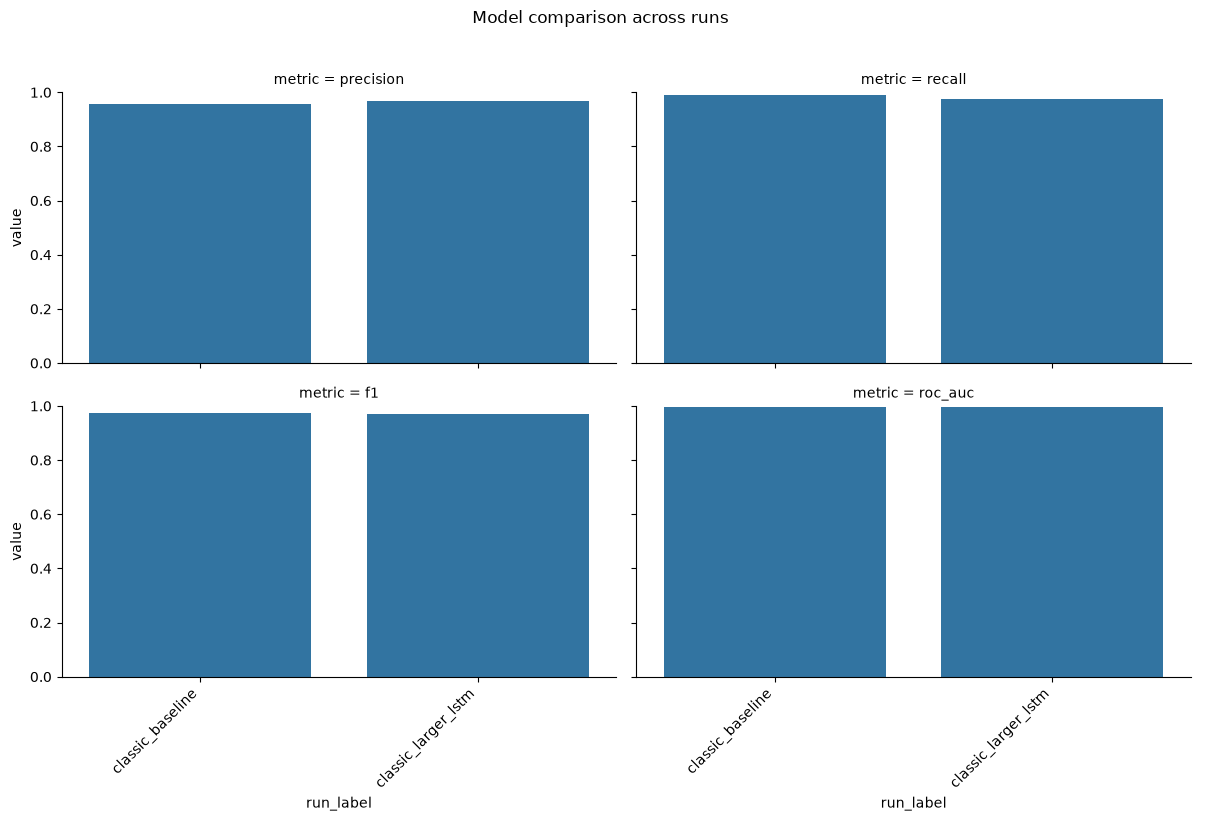

In [17]:
metric_cols = ["metrics_precision", "metrics_recall", "metrics_f1", "metrics_roc_auc"]

plot_data = df_runs.melt(
    id_vars="run_label",
    value_vars=metric_cols,
    var_name="metric",
    value_name="value",
)
plot_data["metric"] = plot_data["metric"].str.removeprefix("metrics_")

g = sns.catplot(
    data=plot_data,
    x="run_label",
    y="value",
    col="metric",
    kind="bar",
    col_wrap=2,
    height=4,
    aspect=1.5,
)
g.set_xticklabels(plot_data["run_label"].unique(), rotation=45, ha="right")
g.set(ylim=(0, 1))
g.fig.suptitle("Model comparison across runs", y=1.02)
g.fig.tight_layout()
plt.show()

In [ ]:
cudnn_labels = ["baseline", "no_cudnn"]
cudnn_comparison = runs[
    (runs["operation"] == "dnn train") & (runs["run_label"].isin(cudnn_labels))
][["run_label", "metrics_precision", "metrics_recall", "metrics_f1", "metrics_roc_auc", "duration_seconds"]]

speedup = cudnn_comparison.set_index("run_label")["duration_seconds"]
print(f"cuDNN speedup: {speedup['no_cudnn'] / speedup['baseline']:.2f}x")

cudnn_comparison